# Оцениваем цены домов

### Подключаем библиотеки

In [126]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso


## Загружаем данные

### Читаем train

In [127]:
data = pd.read_csv("train.csv")
test_raw = pd.read_csv("test.csv")

### Просматриваем строки

In [128]:
print(data.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

### Проверяем данные

In [129]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Чистим данные

### Ищем пропуски

In [130]:
data.isna().sum()[data.isna().sum() > 0]


LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

### Сверяем снова

In [131]:
data.isna().sum()[data.isna().sum() > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

## Кодируем признаки

### Кодируем качество

In [132]:
quality_map_1 = {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}
quality_map_2 = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
quality_map_3 = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
quality_map_4 = {"None": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4}

label = [27, 28, 30, 31, 32, 33, 35, 40, 53, 57, 63, 64, 72]
columns_1 = [32]
columns_2 = [33, 35]
columns_3 = [40, 53, 57, 63, 64, 27, 28, 30, 31]
columns_4 = [72]

def fill_na(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.mean()))
    df['Alley'] = df['Alley'].fillna('None')
    df['MasVnrType'] = df['MasVnrType'].fillna('None')
    df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
    df['BsmtQual'] = df['BsmtQual'].fillna('None')
    df['BsmtCond'] = df['BsmtCond'].fillna('None')
    df['BsmtExposure'] = df['BsmtExposure'].fillna('None')
    df['BsmtFinType1'] = df['BsmtFinType1'].fillna('None')
    df['BsmtFinType2'] = df['BsmtFinType2'].fillna('None')
    df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
    df['FireplaceQu'] = df['FireplaceQu'].fillna('None')
    df['GarageType'] = df['GarageType'].fillna('None')
    df['GarageQual'] = df['GarageQual'].fillna('None')
    df['GarageYrBlt'] = df.groupby('Neighborhood')['GarageYrBlt'].transform(lambda x: x.fillna(x.mean()))
    df['GarageFinish'] = df['GarageFinish'].fillna('None')
    df['GarageCond'] = df['GarageCond'].fillna('None')
    df['PoolQC'] = df['PoolQC'].fillna('None')
    df['Fence'] = df['Fence'].fillna('None')
    df['MiscFeature'] = df['MiscFeature'].fillna('None')

    return df

def map_quality(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()


    for col in columns_1:
        df.iloc[:, col] = df.iloc[:, col].map(quality_map_1)
    for col in columns_2:
        df.iloc[:, col] = df.iloc[:, col].map(quality_map_2)
    for col in columns_3:
        df.iloc[:, col] = df.iloc[:, col].map(quality_map_3)
    for col in columns_4:
        df.iloc[:, col] = df.iloc[:, col].map(quality_map_4)

    return df

def build_ohe_lists(df: pd.DataFrame):
    cat_mask = df.select_dtypes(include=['object']).columns
    cat_idx = [df.columns.get_loc(col) for col in cat_mask]

    for_onehot = [x for x in cat_idx if x not in label]
    for_onehot_names = df.columns[for_onehot]

    return for_onehot_names

def fit_transform_train(train_df: pd.DataFrame):
    df = fill_na(train_df)
    df = map_quality(df)

    for_onehot_names = build_ohe_lists(df)

    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    ohe_array = ohe.fit_transform(df[for_onehot_names])
    ohe_cols = ohe.get_feature_names_out(for_onehot_names)

    ohe_df = pd.DataFrame(ohe_array, columns=ohe_cols, index=df.index)
    df = pd.concat([df.drop(columns=for_onehot_names), ohe_df], axis=1)

    return df, ohe, for_onehot_names

def transform_test(test_df: pd.DataFrame, ohe: OneHotEncoder, for_onehot_names):
    df = fill_na(test_df)
    df = map_quality(df)

    ohe_array = ohe.transform(df[for_onehot_names])
    ohe_cols = ohe.get_feature_names_out(for_onehot_names)

    ohe_df = pd.DataFrame(ohe_array, columns=ohe_cols, index=df.index)
    df = pd.concat([df.drop(columns=for_onehot_names), ohe_df], axis=1)

    return df

### Подготавливаем train

In [133]:
train_proc, ohe, for_onehot_names = fit_transform_train(data)
test_proc = transform_test(test_raw, ohe, for_onehot_names)


## Ищем важные признаки

### Считаем корреляции

Топ 30 признаков, которые коррелириуют с таргетом
SalePrice                1.000000
OverallQual              0.790982
GrLivArea                0.708624
ExterQual                0.682639
KitchenQual              0.659600
GarageCars               0.640409
GarageArea               0.623431
TotalBsmtSF              0.613581
1stFlrSF                 0.605852
BsmtQual                 0.585207
FullBath                 0.560664
TotRmsAbvGrd             0.533723
YearBuilt                0.522897
FireplaceQu              0.520438
YearRemodAdd             0.507101
GarageYrBlt              0.499355
Foundation_PConc         0.497734
MasVnrArea               0.472614
Fireplaces               0.466929
HeatingQC                0.427649
GarageFinish_Fin         0.419678
GarageFinish_Unf         0.410608
Neighborhood_NridgHt     0.402149
BsmtFinSF1               0.386420
BsmtExposure             0.374696
MasVnrType_None          0.367456
SaleType_New             0.357509
GarageType_Detchd        0.35414

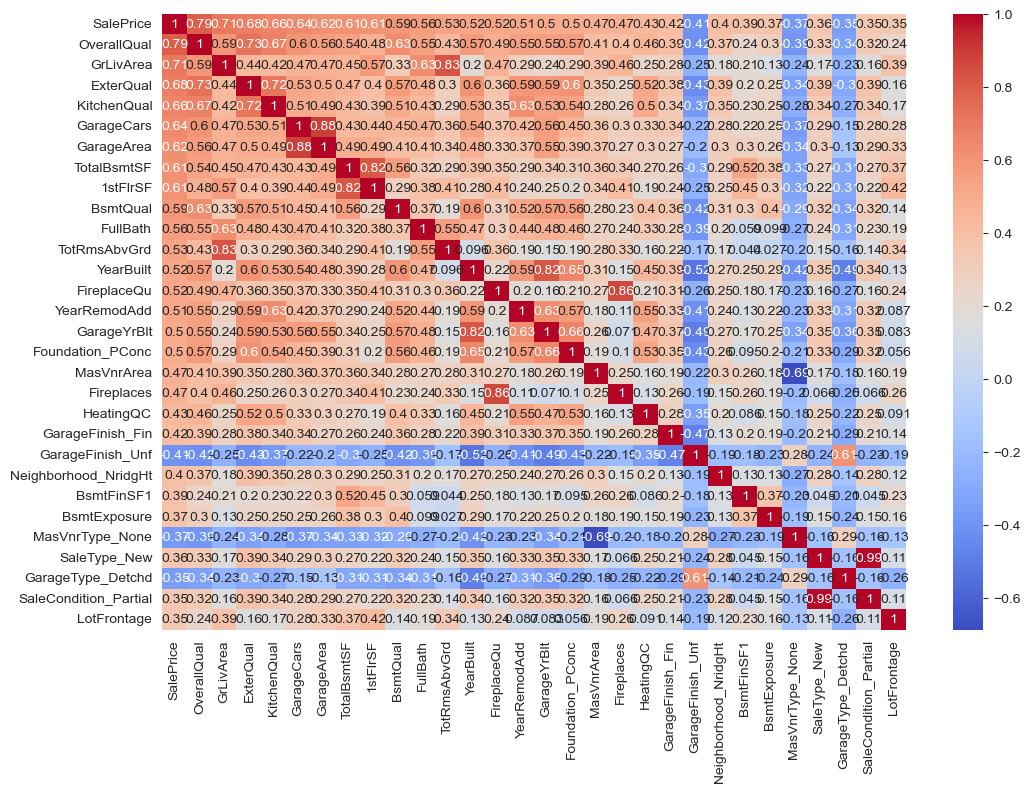

In [134]:
corr = train_proc.corr(method='pearson')
target_corr = corr['SalePrice']
top_30 = abs(target_corr).sort_values(ascending=False).head(30)
print(f'Топ 30 признаков, которые коррелириуют с таргетом\n{top_30}')
selected_features = top_30.index
corr_top = train_proc[selected_features].corr(method='pearson')
plt.figure(figsize=(12, 8))
sns.heatmap(corr_top, annot=True, cmap='coolwarm')
to_drop = []
features = list(corr_top.columns)
for f in range(len(features)):
    for j in range(f):
        if corr_top.iloc[f, j] >= 0.8:
            to_drop.append(features[f])
            break
final_features = [f for f in features if f not in to_drop]
print(f'Финальные признаки, которые будем использовать при обучении модели {final_features}')
data_final = train_proc[final_features]

## Готовим цель

### Логарифмируем цель

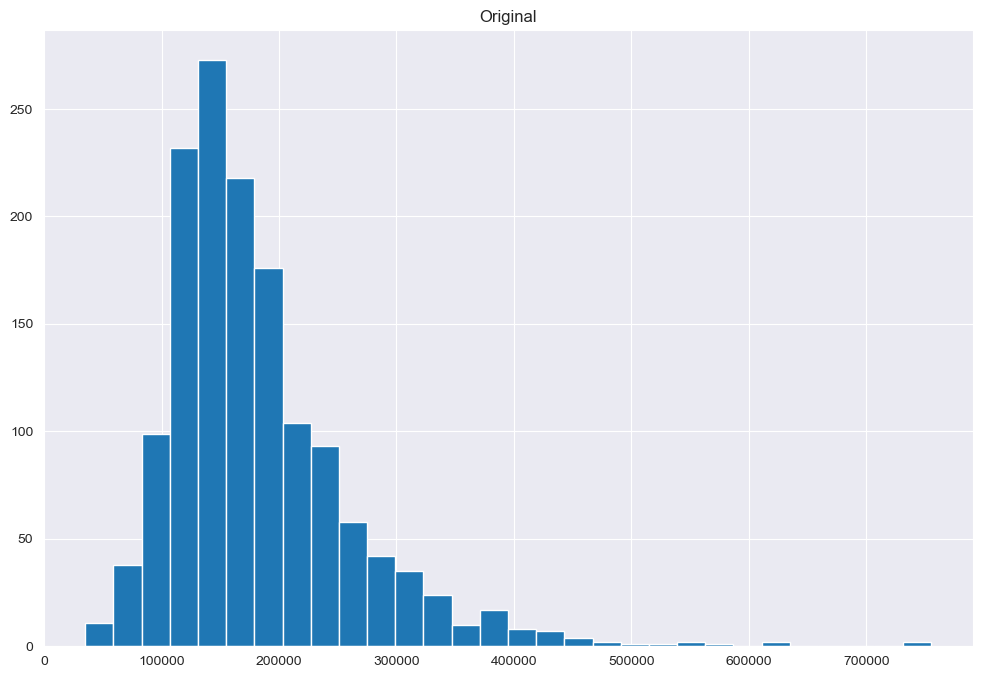

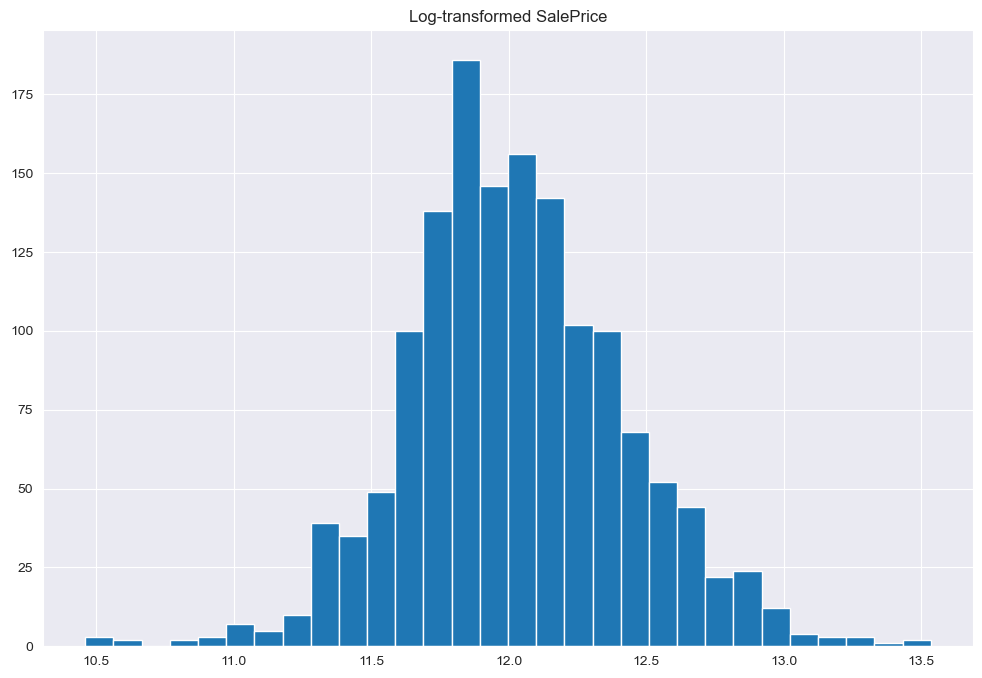

In [135]:
y = data_final['SalePrice']
plt.figure(figsize=(12, 8))
plt.hist(y, bins=30)
plt.title('Original')
plt.show()

y_log = np.log1p(y)

plt.figure(figsize=(12, 8))
plt.hist(y_log, bins=30)
plt.title("Log-transformed SalePrice")
plt.show()

## Обучаем модели

### Собираем признаки

In [136]:
X = data_final.drop('SalePrice', axis=1)
target = y_log

### Делим выборку

In [137]:
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.25, random_state=42)
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


### Подбираем параметры

In [138]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

linear = LinearRegression()
linear.fit(X_train, y_train)
y_pred_linear = linear.predict(X_test)
y_pred_real_linear = np.expm1(y_pred_linear)
y_test_real = np.expm1(y_test)
rmse_linear = np.sqrt(mean_squared_error(y_test_real, y_pred_real_linear))
alphas_ridge = [0.001, 0.01, 0.1, 1, 10, 50, 100]
alphas_lasso = [0.0001, 0.001, 0.01, 0.05, 0.1]
ridge = GridSearchCV(
    estimator=Ridge(),
    param_grid={"alpha": alphas_ridge},
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
y_pred_real_ridge = np.expm1(y_pred_ridge)
y_test_real_ridge = np.expm1(y_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test_real, y_pred_real_ridge))
lasso = GridSearchCV(
    estimator=Lasso(max_iter=20000),
    param_grid={"alpha": alphas_lasso},
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)
lasso.fit(X_train, y_train)
y_pred_Lasso = lasso.predict(X_test)
y_pred_real_Lasso = np.expm1(y_pred_Lasso)
y_test_real_Lasso = np.expm1(y_test)
rmse_Lasso = np.sqrt(mean_squared_error(y_test_real, y_pred_real_Lasso))

## Сравниваем модели

### Оцениваем качество

In [139]:
from sklearn.metrics import r2_score
print(f'Среднекватричная ошибка Linear {rmse_linear:.2f}$\n'
      f'Среднекватричная ошибка Ridge {rmse_ridge:.2f}$\n'
      f'Среднекватричная ошибка Lasso {rmse_Lasso:.2f}$\n')
r2_linear = r2_score(y_test_real, y_pred_real_linear)
r2_ridge = r2_score(y_test_real, y_pred_real_ridge)
r2_lasso = r2_score(y_test_real, y_pred_real_Lasso)
print("R²:\n",f'У модели без регуляризации: {r2_linear:.2f}\n L2-Регуляризация: {r2_ridge:.2f}\n L1-Регуляризация: {r2_lasso:.2f}')

Среднекватричная ошибка Linear 28116.15$
Среднекватричная ошибка Ridge 28114.22$
Среднекватричная ошибка Lasso 29373.73$

R²:
 У модели без регуляризации: 0.89
 L2-Регуляризация: 0.89
 L1-Регуляризация: 0.88


### Смотрим коэффициенты

In [140]:
coef_linear = linear.coef_
coef_ridge = ridge.best_estimator_.coef_
coef_lasso = lasso.best_estimator_.coef_

### Рисуем сравнение

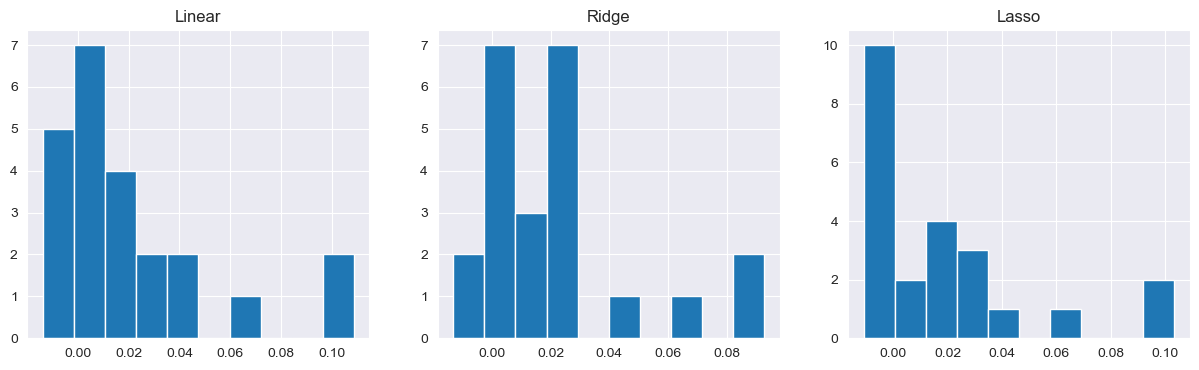

In [141]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(coef_linear)
axes[0].set_title("Linear")

axes[1].hist(coef_ridge)
axes[1].set_title("Ridge")

axes[2].hist(coef_lasso)
axes[2].set_title("Lasso")

plt.show()


## Формулируем итоги

### Готовим submission

In [146]:
X = data_final.drop("SalePrice", axis=1)
y = y_log
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)


final_model = Ridge(alpha=ridge.best_params_["alpha"])
final_model.fit(X_scaled, y)

X_kaggle = test_proc.reindex(columns=X.columns, fill_value=0)
X_kaggle_scaled = scaler_final.transform(X_kaggle)

pred_log = final_model.predict(X_kaggle_scaled)
pred = np.expm1(pred_log)

# --- 6) Submission ---
submission = pd.DataFrame({
    "Id": test_raw["Id"],
    "SalePrice": pred
})
submission.to_csv("submission.csv", index=False)

print("saved: submission.csv")
submission.head()

saved: submission.csv


C:\Users\myska\AppData\Local\Temp\ipykernel_3708\2937366912.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_kaggle = X_kaggle.fillna(0).infer_objects(copy=False)


,Id,SalePrice
0,1461,110882.559584
1,1462,138914.345557
2,1463,173915.793147
3,1464,193588.357685
4,1465,188643.773135


### Показываем график
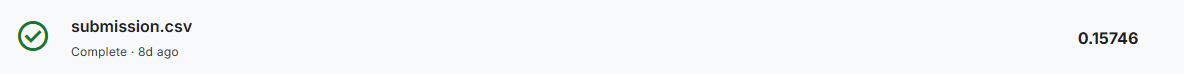